# 📉 02-机器学习 · 推导笔记 5：PCA 主成分分析（手写三视角）

> PCA 是**无监督降维第一名**，也是面试手推必考题：最大化方差 ↔ 最小化重构误差 ↔ 特征分解 ↔ SVD。
> 本 notebook 要求：**从中心化、协方差矩阵到特征分解全部手写，不调 sklearn.decomposition**。

**运行环境**：Python 3.8+，仅依赖 numpy（`eigh`/`svd` 属数值原语）。

## 📖 本章导读

> **这一章讲什么**（全书第 11 章）：降维为什么等价于「最大化投影方差」；用拉格朗日乘子推出**特征分解** $\Sigma w=\lambda w$；再给 SVD 视角，最后对比有监督的 LDA。

**学完本章，你应该能**：
1. 手推 $\Sigma w=\lambda w$（最大化 $w^\top\Sigma w$，约束 $w^\top w=1$）；
2. 解释方差占比 $\sum_{i\le k}\lambda_i/\sum\lambda_i$ 与信息损失（被舍弃特征值之和）；
3. 说清 PCA 与 SVD 的关系（右奇异向量 = 主成分方向）；
4. 对比 PCA（无监督最大方差）与 LDA（有监督最大类间/类内比）。

> 📌 全书第 11 章，手推必考题。阅读路径：本章导读 → 最大方差 · 特征分解 · SVD → 自测清单 → 本章小结。

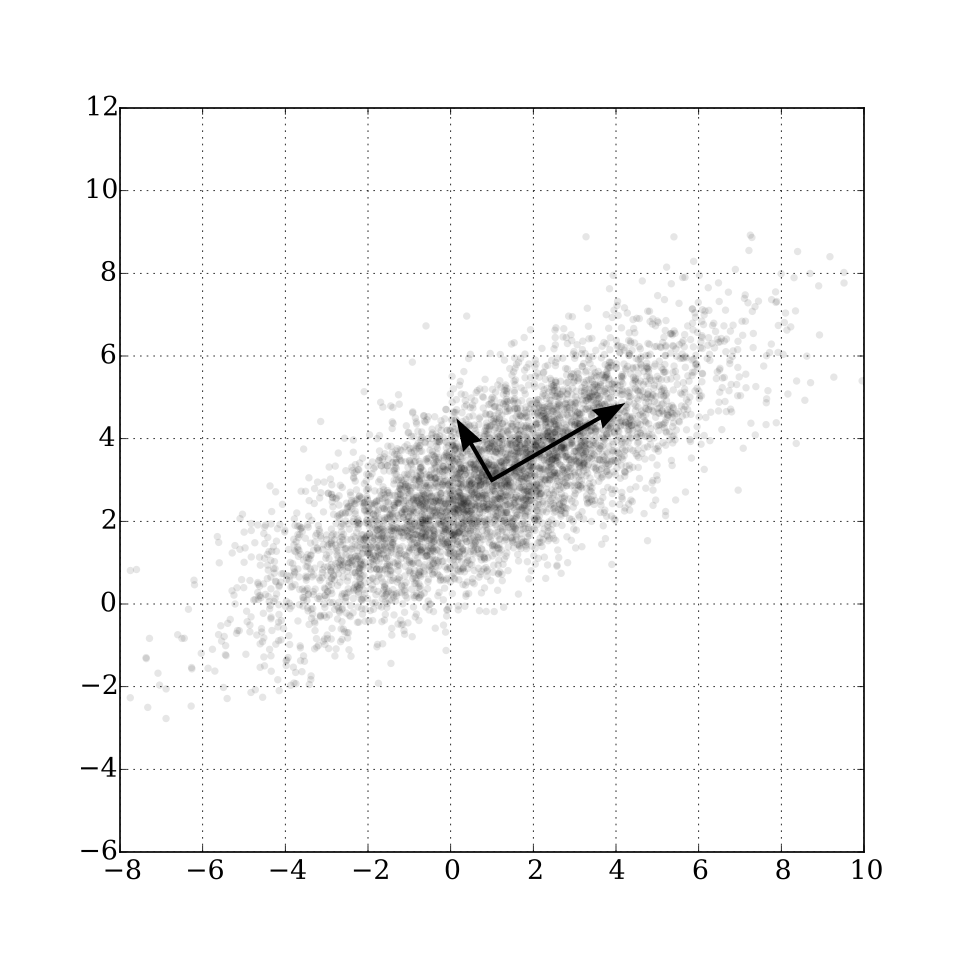

> 📷 PCA：把二维散点投影到方差最大的方向（第一主成分）
> *图源：Wikimedia Commons（开放授权）*


> 💡 **一句话类比——「拍侧面照」**：给一个 3D 物体拍一张 2D 照片，就是从不同角度「降维」，角度选得好（主成分方向），正视图依然能看清物体全貌；角度选得差（沿着某个被遮挡的方向），信息全丢了。PCA 就是**自动找到最能保留信息的那一批拍摄角度**。

## §1 两个等价视角（先建立直觉）

### 视角一：最大化投影方差

找方向 $u$，使数据投影 $Xu$ 的方差最大（保留最多的信息）：

$$\max_{u: \|u\|=1} \operatorname{Var}(Xu) = \max_u u^{\top} \Sigma u$$

其中 $\Sigma$ 是特征协方差矩阵。

### 视角二：最小化重构误差

用 $k$ 维子空间重构原数据，最小化平方误差：

$$\min_{U} \| X - XUU^{\top} \|_F^2$$

两个目标解出的 $U$ 相同——**PCA 即最优 k 维线性子空间**。

## §2 中心化与协方差矩阵

**中心化**（去掉均值，PCA 必须）：

$$\tilde{X} = X - \bar{x} \mathbf{1}^{\top}$$

**样本协方差矩阵**：

$$\Sigma = \frac{1}{n-1} \tilde{X}^{\top} \tilde{X} \ \in \mathbb{R}^{d \times d}$$

（无偏估计用 $n-1$；PCA 常用 $n$ 或 $n-1$，只影响特征值尺度不影响方向。）

## §3 特征分解推导（拉格朗日乘子法）

最大化问题（第一主成分方向 $u_1$）：

$$\max u^{\top}\Sigma u \quad \text{s.t.} \quad u^{\top}u = 1$$

拉格朗日函数：

$$\mathcal{L} = u^{\top}\Sigma u - \lambda(u^{\top}u - 1)$$

对 $u$ 求导置零：

$$\frac{\partial \mathcal{L}}{\partial u} = 2\Sigma u - 2\lambda u = 0 \ \Rightarrow \ \Sigma u = \lambda u$$

**结论**：$u_1$ 是 $\Sigma$ 最大特征值对应的特征向量！方差 = 特征值 $\lambda_1$。

**第 k 个主成分**：第 k 大特征值的特征向量，与前面正交（对称矩阵特征向量正交）。

**方差解释率**：

$$\text{解释率}_k = \frac{\lambda_k}{\sum_j \lambda_j}$$

**SVD 视角**：$\tilde{X} = U S V^{\top}$，则 $\tilde{X}^{\top}\tilde{X} = V S^2 V^{\top}$——**右奇异向量 = 特征向量，奇异值² = 特征值**（数值上 SVD 更稳）。

In [ ]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.k = n_components
        self.mean_ = None
        self.components_ = None      # [k, d] 主成分方向（行）
        self.explained_ratio_ = None
        self.eigenvalues_ = None
        self.cov_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_                          # 1. 中心化
        self.cov_ = Xc.T @ Xc / (len(X) - 1)         # 2. 协方差矩阵（输出检查）
        eigvals, eigvecs = np.linalg.eigh(self.cov_) # 3. 对称矩阵特征分解
        order = np.argsort(eigvals)[::-1]            # 4. 特征值降序
        self.eigenvalues_ = eigvals[order]
        self.components_ = eigvecs[:, order[:self.k]].T
        self.explained_ratio_ = self.eigenvalues_ / self.eigenvalues_.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T   # 5. 投影

    def reconstruct(self, Z):
        # 用 k 个主成分重构原数据（评估信息损失）
        return Z @ self.components_ + self.mean_

rng = np.random.default_rng(0)
# 构造椭圆分布：x1 方差大、x2 方差小、x1-x2 相关
X = rng.normal(0, 1, (200, 2)) @ np.array([[3.0, 1.5], [0.5, 1.0]]) + 2.0

pca = PCA(n_components=2).fit(X)
print('协方差矩阵（中间量）:')
print(np.round(pca.cov_, 3))
print('特征值(降序) =', np.round(pca.eigenvalues_, 3))       # 第一个应显著更大
print('方差解释率 =', np.round(pca.explained_ratio_, 3))
print('第一主成分方向 u1 =', np.round(pca.components_[0], 3))
projected = pca.transform(X)
print('投影后第一维方差 =', round(np.var(projected[:, 0]), 3), '（应 ≈ λ1）')
print('投影后第二维方差 =', round(np.var(projected[:, 1]), 3), '（应 ≈ λ2）')
rec = pca.reconstruct(projected)
print('k=2 重构均方误差 =', round(np.mean((rec - X) ** 2), 6), '（满秩应≈0）')

## §4 降维与信息保留示例（中间输出）

**给定 k，重构误差**：

$$\text{重构误差} = \sum_{j=k+1}^{d} \lambda_j \quad (\text{丢掉的方差 = 被舍弃特征值之和})$$

**选 k 的准则**：累积解释率到达阈值（如 90%）或特征值拐点（碎石图）。

**示例**：20 维合成数据（只有前 5 维有信号），看 PCA 找出的主成分数与解释率累积曲线。

In [ ]:
rng = np.random.default_rng(1)
n, d = 300, 20
# 真实信号只在前 5 维：x1..x5 方差大，其余是噪声
X20 = np.zeros((n, d))
X20[:, :5] = rng.normal(0, [4, 3, 2, 1.5, 1], (n, 5))
X20[:, 5:] = rng.normal(0, 0.2, (n, d - 5))

pca20 = PCA(n_components=d).fit(X20)
cum = np.cumsum(pca20.explained_ratio_)
print('前 10 个特征值:')
print(np.round(pca20.eigenvalues_[:10], 3))
print('累计解释率（前 6 个）:', np.round(cum[:6], 4))
print('解释率 >90% 需要 k =', int(np.argmax(cum >= 0.90)) + 1, '（真实信号维度 5，合理！）')

# 中间检查：逐 k 的重构误差 = 被舍弃特征值之和
for k in [1, 3, 5, 10]:
    p = PCA(n_components=k).fit(X20)
    Z = p.transform(X20)
    rec_err = np.mean((p.reconstruct(Z) - X20) ** 2)
    tail = pca20.eigenvalues_[k:].sum() / (n - 1)   # 理论：被丢特征值均值
    print(f'k={k:2d}: 实际重构MSE={rec_err:.5f}  理论(被丢特征值/n)={tail:.5f}')

## §5 SVD 实现与数值稳定性（对照）

直接算 $\tilde{X}^{\top}\tilde{X}$ 会平方条件数（精度损失）。**数值上更稳**：

$$\tilde{X} = U S V^{\top} \ \Rightarrow \ \text{主成分} = V \text{ 的列}, \quad \text{方差} = \frac{s_j^2}{n-1}$$

两者在精确算术下等价，SVD 版更稳（不显式构造协方差矩阵）。

In [ ]:
class PCASVD:
    def __init__(self, n_components):
        self.k = n_components
        self.mean_ = None
        self.components_ = None
        self.singular_values_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)   # Xc = U S Vt
        self.singular_values_ = S
        self.components_ = Vt[:self.k]
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

# 奇异值² 与特征分解特征值对照（应一致）
p1 = PCA(n_components=5).fit(X20)
p2 = PCASVD(n_components=5).fit(X20)
eig_by_svd = p2.singular_values_[:5] ** 2 / (len(X20) - 1)
print('特征分解特征值 :', np.round(p1.eigenvalues_[:5], 4))
print('SVD 奇异值²/(n-1) :', np.round(eig_by_svd, 4))
print('两种实现一致:', np.allclose(p1.eigenvalues_[:5], eig_by_svd, atol=1e-8))
print('主成分方向一致:', np.allclose(np.abs(p1.components_), np.abs(p2.components_), atol=1e-8))

## §6 实际应用示例：图像压缩（中间过程）

每张 8×8 灰度图 = 64 维向量。用 PCA 取 k 个主成分压缩：原始存 64 个数 → 存 k 个投影系数 + k×64 主成分。

**压缩率**：

$$\text{存储比} = \frac{k \cdot (64 + 1)}{64 \cdot N} \quad (N \text{ 张图，共享主成分})$$

下面用手写数据模拟 50 张带噪声的「8 型」图案，观察 k 增大时重构误差下降。

In [ ]:
rng = np.random.default_rng(2)
N = 50
# 基础图案：4 个 8x8 模板，再叠加平移/噪声生成多样本
base = np.zeros((4, 64))
for t in range(4):
    img = np.zeros((8, 8))
    img[t:(t+3), t:(t+3)] = 1.0      # 左上角方块
    img[6-t:8, 6-t:8] = 0.8          # 右下角方块
    base[t] = img.ravel()
Ximg = np.vstack([base[t % 4] + rng.normal(0, 0.15, 64) for t in range(N)])  # 4 个模板循环使用 + 噪声

print('  k |  重构MSE  | 压缩存储/原始  ')
for k in [2, 4, 8, 16, 32]:
    p = PCA(n_components=k).fit(Ximg)
    Z = p.transform(Ximg)
    rec = p.reconstruct(Z)
    mse = np.mean((rec - Ximg) ** 2)
    ratio = k * (64 + 1) / (64 * N)
    print(f'  {k:2d} |  {mse:.5f}  |    {ratio:.4f}')
print('观察：k=8 即可低误差重建（模板只有 3 个自由度）')
print('首样本前 16 个像素（原始 | k=4重构）:')
p4 = PCA(n_components=4).fit(Ximg)
rec4 = p4.reconstruct(p4.transform(Ximg))
print('原始   :', np.round(Ximg[0, :16], 1))
print('重构   :', np.round(rec4[0, :16], 1))

## §7 常见 bug 与边界（面试踩坑区）

- **忘记中心化**：不减去均值时第一主成分会被均值方向主导（PCA 要求数据居中）
- **特征是否标准化**：量纲差 1000 倍的列会主导协方差——先 z-score（尤其特征单位不同时）
- **eigh vs eig**：协方差对称，用 `eigh`（数值稳定、保证实特征值）；`eig` 可能有复数噪声
- **特征值排序**：`eigh` 默认升序——必须 `argsort()[::-1]`
- **方差解释率分母**：用全特征值之和，不是只算保留的
- **训练/测试中心化一致**：transform 时要用**训练集** mean，不能用测试集自己的 mean（信息泄漏）
- **与线性回归混淆**：PCA 无监督（不碰 y）、最小化正交误差；回归最小化垂直误差、用 y 监督

## §8 面试追问与扩展（加分项）

### 8.1 PCA 与 SVD 的关系（一句话）

$\tilde{X} = U S V^{\top}$ 时，$\tilde{X}^{\top}\tilde{X} = V S^2 V^{\top}$——SVD 的右奇异向量就是协方差矩阵的特征向量，奇异值平方就是特征值；且 SVD 无需构造协方差矩阵，数值更稳。

### 8.2 为什么特征值大的方向信息多

方差 = 信息量的朴素度量（高斯数据下，MSE 重构损失 = 被丢掉的特征值之和）。

### 8.3 变体

- **KPCA**：核化 PCA（先映射再 PCA）
- **白化**：除以 $\sqrt{\lambda_j}$ 使各主成分方差为 1
- **PCA vs LDA**：LDA 用类别标签（监督）、最大化类间/类内比

### 8.4 工程注意

- 大数据集用随机化 SVD / 增量 PCA（在线更新）
- 主成分方向可解释性：载荷（components 行）绝对值大的特征即该方向的主载

## 补充 · LDA 线性判别分析（二分类推导）

LDA 是**有监督降维**：利用类别标签找一个投影方向 $w$，使投影后「类间距离最大、类内散度最小」（最大化可分性）。二分类推导如下。

**类内散度矩阵**（within-class scatter）：
$$S_W = \sum_{k=1}^{2}\sum_{i \in k}(x_i - \mu_k)(x_i - \mu_k)^{\top}$$

**类间散度矩阵**（between-class scatter，二分类秩为 1）：
$$S_B = (\mu_1 - \mu_2)(\mu_1 - \mu_2)^{\top}$$

**目标函数**：最大化广义瑞利商
$$J(w) = \frac{w^{\top} S_B w}{w^{\top} S_W w}$$

对 $w$ 求导并令导数为零：
$$\frac{\partial J}{\partial w} = 0 \;\Longrightarrow\; S_W^{-1} S_B w = \lambda w$$

即 $w$ 是 $S_W^{-1} S_B$ 的最大特征值对应的特征向量（**广义特征值问题**）。二分类时 $S_B$ 秩为 1，解退化为一维方向：**$w \propto S_W^{-1}(\mu_1 - \mu_2)$**——先按类内散度白化，再取两均值差的方向。

**PCA vs LDA 对比**：

| 维度 | PCA | LDA |
| --- | --- | --- |
| 学习方式 | 无监督 | 有监督 |
| 优化目标 | 最大投影方差 | 最大类间/类内散度比（最大可分） |
| 是否利用标签 | 不利用 | 利用标签 |
| 适用场景 | 降维 / 去相关 | 降维 + 分类（监督） |


In [ ]:
# 手写二分类 LDA：S_W -> w = S_W^{-1}(mu1-mu2) -> 投影 + 阈值分类，并与 sklearn 对照方向
import numpy as np
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=0)

# 1) 类内散度 S_W 与两类别均值
classes = np.unique(y)
mu = {k: X[y == k].mean(axis=0) for k in classes}
S_W = np.zeros((X.shape[1], X.shape[1]))
for k in classes:
    Xk = X[y == k] - mu[k]
    S_W += Xk.T @ Xk

# 2) 投影方向：w = S_W^{-1} (mu1 - mu2)
w = np.linalg.inv(S_W) @ (mu[1] - mu[0])

# 3) 投影 + 用两均值投影中点做阈值分类
proj = X @ w
thr = (proj[y == 1].mean() + proj[y == 0].mean()) / 2
pred = (proj > thr).astype(int)
acc = (pred == y).mean()
print('手写 LDA 准确率 = %.4f' % acc)

# 4) 与 sklearn LDA 方向对比：归一化后相关系数应接近 ±1
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
w_norm = w / np.linalg.norm(w)
sk_norm = lda.coef_[0] / np.linalg.norm(lda.coef_[0])
corr = np.corrcoef(w_norm, sk_norm)[0, 1]
print('手写 w 与 sklearn coef_ 归一化方向相关系数 = %.4f (|corr| = %.4f)' % (corr, abs(corr)))


**几何直觉：PCA vs LDA**：PCA 只盯着数据本身的方差——找「投影后方差最大」的方向，完全不在乎点属于哪一类；LDA 则看向类别——找「投影后两类均值离得远、类内散得近」的方向，本质是在方差与类别可分性之间做取舍。一句话：PCA 回答「数据沿哪个方向变化最剧烈」，LDA 回答「沿哪个方向两类最好分开」。


## §9 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 写出最大化投影方差的优化问题
- [ ] 2. 用拉格朗日乘子法推导 $\Sigma u = \lambda u$
- [ ] 3. 解释特征值 = 该方向方差
- [ ] 4. 手写 PCA：中心化→协方差→eigh→排序→投影
- [ ] 5. 手写方差解释率与累积解释率
- [ ] 6. 解释为什么必须中心化
- [ ] 7. 特征量纲不同时怎么办（标准化）
- [ ] 8. 说明 PCA 是无监督方法
- [ ] 9. 写出重构误差与特征值关系
- [ ] 10. 选 k 的两种准则（阈值/拐点）

### L2 进阶（10 问）

- [ ] 11. 推导最小化重构误差视角与最大化方差等价
- [ ] 12. 手写 SVD 版 PCA 并与特征分解对照
- [ ] 13. PCA 白化手写
- [ ] 14. 训练/测试集均值一致的注意点示例
- [ ] 15. PCA vs LDA 对比（目标与监督性）
- [ ] 16. 手写 KPCA（RBF 核）概念版
- [ ] 17. 载荷/因子解释（可解释性）
- [ ] 18. 图像压缩完整示例（k 与存储比）
- [ ] 19. 特征值相乘不变性（旋转后）验证
- [ ] 20. 增量 PCA（在线更新均值与协方差）手写

### L3 挑战（5 问）

- [ ] 21. 证明：主成分逐项正交且方差递减
- [ ] 22. 概率 PCA（PPCA，EM 视角）推导
- [ ] 23. 随机化 SVD 原理（功率迭代）
- [ ] 24. 流形降维对比：t-SNE / UMAP vs PCA
- [ ] 25. 推导 PCA 与最小二乘子空间拟合的统一性

### 自测要点

- 10 分钟内盲写：PCA 类（numpy，含解释率）
- 白板推导拉格朗日 → $\Sigma u = \lambda u$ 链路
- 讲清 PCA/SVD/LDA 三者关系（1 分钟版）

## 附录：参考与下节预告

- 《统计学习方法》第 16 章（PCA）
- PRML 第 12 章（主成分分析）

### 下节预告：推导笔记 6 — GBDT（手写回归树 + 负梯度 + 学习率）

> 💡 本笔记验收：`02-机器学习/README.md` 验收清单「PCA 必含」打勾。

## 🏁 本章小结

- **原理一句话**：PCA = **最大化投影方差** → 协方差矩阵特征分解；方差占比 = 特征值占比。
- **必会公式**：$\Sigma w=\lambda w$（拉格朗日）；保留比例 $\frac{\sum_{i\le k}\lambda_i}{\sum\lambda_i}$；重建误差 = 被舍弃特征值之和。
- **面试怎么考**：拉格朗日推导；为什么先去均值；PCA vs SVD（右奇异向量 = 主成分）；PCA vs LDA（无监督 vs 有监督）。
- **易错点**：特征不标准化（量纲大的特征主导）；直接用原始数据算协方差而不是中心化后。

> 自测清单没把握的条目，回到对应小节重读后再打勾。